In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('train.csv')

target_col = 'SalePrice' 
X = df.drop(columns=[target_col])
y = df[target_col]


In [5]:
# Separate categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'string']).columns
numeric_cols = X.select_dtypes(exclude=['object', 'string']).columns

# Impute missing values
num_imputer = SimpleImputer(strategy='median')
X_numeric = pd.DataFrame(num_imputer.fit_transform(X[numeric_cols]), columns=numeric_cols)

cat_imputer = SimpleImputer(strategy='most_frequent')
X_categorical = pd.DataFrame(cat_imputer.fit_transform(X[categorical_cols]), columns=categorical_cols)

# One-hot encode categorical columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(X_categorical)
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(categorical_cols))

# Combine numeric + encoded features
X_processed = pd.concat([X_numeric.reset_index(drop=True),
                         encoded_df.reset_index(drop=True)], axis=1)


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [7]:

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [8]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


R² Score: 0.9177
MAE: 15668.55
RMSE: 25120.78


In [9]:
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_processed.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 20 Important Features:")
print(feature_importance.head(20))



Top 20 Important Features:
                   feature  importance
4              OverallQual    0.235762
26              GarageCars    0.095492
19                FullBath    0.049849
170           ExterQual_TA    0.032091
217           CentralAir_N    0.030796
248       GarageFinish_Unf    0.029179
16               GrLivArea    0.028847
182            BsmtQual_Ex    0.022332
50         LandContour_Bnk    0.020891
262              PoolQC_Ex    0.020556
224         KitchenQual_Ex    0.017274
245      GarageType_Detchd    0.015086
218           CentralAir_Y    0.013493
14                2ndFlrSF    0.013204
169           ExterQual_Gd    0.012854
79    Neighborhood_NoRidge    0.012703
184            BsmtQual_Gd    0.011064
126       RoofMatl_CompShg    0.010893
287  SaleCondition_Partial    0.009899
240      GarageType_2Types    0.009531


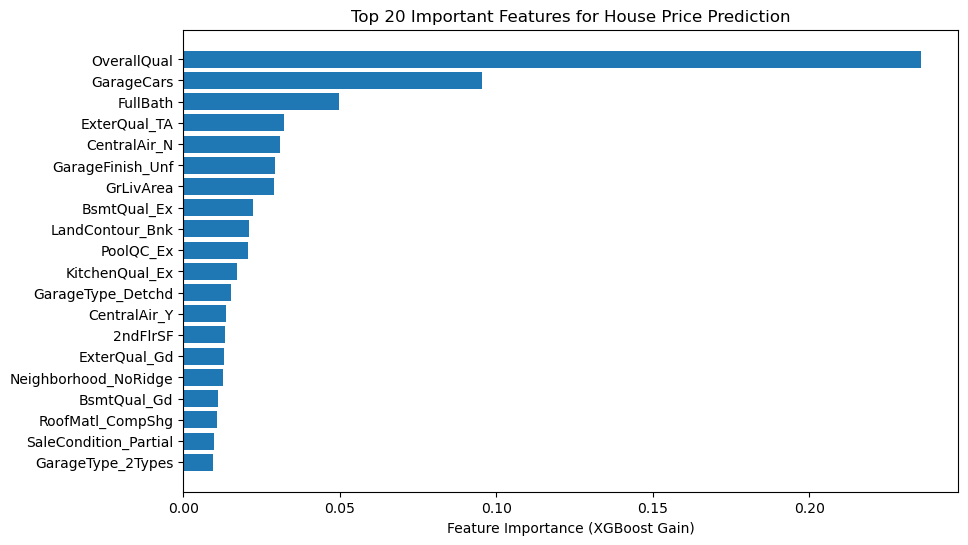

In [10]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'][:20], feature_importance['importance'][:20])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance (XGBoost Gain)")
plt.title("Top 20 Important Features for House Price Prediction")
plt.show()


In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=81)
pca.fit(encoded_df)


PCA(n_components=81)

In [14]:
# Create a DataFrame for variance explained per component
explained_var_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance Ratio': pca.explained_variance_ratio_
})

print(explained_var_df)
print("\nTotal Variance Explained:", pca.explained_variance_ratio_.sum())


   Principal Component  Explained Variance Ratio
0                  PC1                  0.154224
1                  PC2                  0.061475
2                  PC3                  0.041692
3                  PC4                  0.033871
4                  PC5                  0.028955
..                 ...                       ...
76                PC77                  0.002195
77                PC78                  0.002087
78                PC79                  0.002078
79                PC80                  0.001999
80                PC81                  0.001924

[81 rows x 2 columns]

Total Variance Explained: 0.93232594943284


In [15]:
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

In [16]:
alpha_grid = np.logspace(-3, 3, 60)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_cv = RidgeCV(alphas=alpha_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)
ridge_best_alpha = float(ridge_cv.alpha_)
ridge_best_pred = ridge_cv.predict(X_test_scaled)

lasso_cv = LassoCV(alphas=alpha_grid, cv=5, random_state=42, max_iter=20000, n_jobs=-1)
lasso_cv.fit(X_train_scaled, y_train)
lasso_best_alpha = float(lasso_cv.alpha_)
lasso_best_pred = lasso_cv.predict(X_test_scaled)

def regression_metrics(y_true, y_pred):
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred)
    }

results = []

def collect(model_name, variant, alpha, preds):
    metrics = regression_metrics(y_test, preds)
    metrics.update({'model': model_name, 'variant': variant, 'alpha': alpha})
    results.append(metrics)

collect('Ridge', 'optimal', ridge_best_alpha, ridge_best_pred)
collect('Lasso', 'optimal', lasso_best_alpha, lasso_best_pred)

ridge_double_alpha = ridge_best_alpha * 2
ridge_double = Ridge(alpha=ridge_double_alpha)
ridge_double.fit(X_train_scaled, y_train)
ridge_double_pred = ridge_double.predict(X_test_scaled)
collect('Ridge', 'double', ridge_double_alpha, ridge_double_pred)

lasso_double_alpha = lasso_best_alpha * 2
lasso_double = Lasso(alpha=lasso_double_alpha, max_iter=20000)
lasso_double.fit(X_train_scaled, y_train)
lasso_double_pred = lasso_double.predict(X_test_scaled)
collect('Lasso', 'double', lasso_double_alpha, lasso_double_pred)

results_df = pd.DataFrame(results)
display(results_df)

optimal = results_df[results_df['variant'] == 'optimal'].set_index('model')
double = results_df[results_df['variant'] == 'double'].set_index('model')
comparison = optimal.join(double, lsuffix='_optimal', rsuffix='_double')
for metric in ['rmse', 'mae', 'r2']:
    comparison[f'{metric}_delta'] = comparison[f'{metric}_double'] - comparison[f'{metric}_optimal']
display(comparison.reset_index())

print(f"Best Ridge alpha: {ridge_best_alpha:.6f}")
print(f"Best Lasso alpha: {lasso_best_alpha:.6f}")

,rmse,mae,r2,model,variant,alpha
0,30896.592399,18418.354495,0.875546,Ridge,optimal,626.051657
1,28325.012205,16534.189886,0.895401,Lasso,optimal,1000.000000
2,33097.888889,19156.713662,0.857181,Ridge,double,1252.103314
3,29681.183408,17295.252180,0.885145,Lasso,double,2000.000000


,model,rmse_optimal,mae_optimal,r2_optimal,variant_optimal,alpha_optimal,rmse_double,mae_double,r2_double,variant_double,alpha_double,rmse_delta,mae_delta,r2_delta
0,Ridge,30896.592399,18418.354495,0.875546,optimal,626.051657,33097.888889,19156.713662,0.857181,double,1252.103314,2201.296490,738.359167,-0.018366
1,Lasso,28325.012205,16534.189886,0.895401,optimal,1000.000000,29681.183408,17295.252180,0.885145,double,2000.000000,1356.171203,761.062294,-0.010256


Best Ridge alpha: 626.051657
Best Lasso alpha: 1000.000000


In [17]:
feature_names = X_train.columns
ridge_double_importance = (
    pd.DataFrame({'feature': feature_names, 'coefficient': ridge_double.coef_})
      .assign(abs_coef=lambda d: d['coefficient'].abs())
      .sort_values('abs_coef', ascending=False)
)
lasso_double_importance = (
    pd.DataFrame({'feature': feature_names, 'coefficient': lasso_double.coef_})
      .assign(abs_coef=lambda d: d['coefficient'].abs())
      .sort_values('abs_coef', ascending=False)
)

print('\nTop predictors for Ridge (double alpha):')
display(ridge_double_importance.head(15))

non_zero_lasso = lasso_double_importance[lasso_double_importance['abs_coef'] > 0]
print('\nTop predictors for Lasso (double alpha):')
display(non_zero_lasso.head(15))

if non_zero_lasso.empty:
    print('Lasso with doubled alpha shrunk all coefficients to zero. Consider reducing alpha for sparse signal.')


Top predictors for Ridge (double alpha):


,feature,coefficient,abs_coef
16,GrLivArea,5833.400827,5833.400827
4,OverallQual,5627.714728,5627.714728
125,RoofMatl_ClyTile,-5200.708698,5200.708698
224,KitchenQual_Ex,4617.189933,4617.189933
182,BsmtQual_Ex,4557.562672,4557.562672
13,1stFlrSF,4326.575153,4326.575153
23,TotRmsAbvGrd,4188.746293,4188.746293
79,Neighborhood_NoRidge,3753.693002,3753.693002
12,TotalBsmtSF,3712.082028,3712.082028
26,GarageCars,3581.925752,3581.925752



Top predictors for Lasso (double alpha):


,feature,coefficient,abs_coef
16,GrLivArea,25049.410500,25049.410500
4,OverallQual,14739.393867,14739.393867
125,RoofMatl_ClyTile,-13934.674618,13934.674618
182,BsmtQual_Ex,7026.882861,7026.882861
224,KitchenQual_Ex,6221.444163,6221.444163
6,YearBuilt,6118.689285,6118.689285
9,BsmtFinSF1,6091.097010,6091.097010
102,Condition2_PosN,-6045.938098,6045.938098
12,TotalBsmtSF,5430.484094,5430.484094
79,Neighborhood_NoRidge,4865.735552,4865.735552


You have determined the optimal value of lambda for ridge and lasso regression during the assignment. Now, which one will you choose to apply and why

so choose between ridge and alpha i can take out variance explained by top k features and whichever will be more, i will choose that

After building the model, you realised that the five most important predictor variables in the lasso model are not available in the incoming data. You will now have to create another model excluding the five most important predictor variables. Which are the five most important predictor variables now

next 5, so or this purpose i have found out top 10 important features for both

How can you make sure that a model is robust and generalisable? What are the implications of the same for the accuracy of the model and why

methods:
cross-validation.
regularisation, dropout, early stopping, and simpler models.
make sure data is clean, diverse, balanced, and representative
test on noisy or out-of-distribution data for robustness.

training accuracy may slightly decrease, test accuracy improves, ensuring stable performance on unseen data. Overfitted models may show high training accuracy but fail in real-world scenarios, whereas generalisable models provide reliable predictions across diverse conditions.